# 04. Подготовка датасета Bank Customer Behavior & Churn к кластеризации

**Цель ноутбука** — разобраться в доменной области, проверить гипотезы о структуре данных на графиках и на их основе
собрать матрицу признаков, на которой в ноутбуке `05_clustering_dataset.ipynb` будут обучаться алгоритмы кластеризации.

План:

1. Загрузка данных и первичный осмотр.
2. Описание доменной области: группы колонок, ожидаемые взаимосвязи, ограничения для модели, гипотезы.
3. Проверка качества данных (пропуски, дубликаты, допустимые диапазоны, согласованность дат).
4. Визуализация и проверка гипотез.
5. Подготовка данных: очистка, конструирование признаков, отбор признаков, трансформации, разбиение train / test.
6. Сохранение результата для ноутбука 05.

In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

from modules import style
from modules.style import (GREEN, BLUE, YELLOW, GRAY, GRAY_LIGHT, GREEN_DARK, MINT, ERROR_RED,
                   CHURN_COLOR, STAY_COLOR, ACTIVE_COLOR, INACTIVE_COLOR, HIGHLIGHT_LINE,
                   CATEGORY_PALETTE, DIVERGING_CMAP, SEQUENTIAL_CMAP, category_color)

warnings.filterwarnings("ignore")
style.apply_default_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
DATA_DIR = Path("data")
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df_raw = pd.read_csv(DATA_DIR / "bank_churn_dataset.csv")
print("Размер:", df_raw.shape)
df_raw.head()

Размер: (80000, 26)


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [3]:
info = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
    "example": df_raw.iloc[0],
})
info

,dtype,n_unique,n_missing,example
id,int64,80000,0,1
full_name,str,5100,0,Đặng Văn Vũ
credit_sco,int64,291,0,725
gender,str,2,0,male
age,int64,71,0,55
occupation,str,10,0,Chủ Doanh nghiệp nhỏ
balance,int64,79920,0,177306004
monthly_ir,int64,209,0,121000000
address,str,16,0,Phường An Hội (BT)
origin_province,str,9,0,TP. Hồ Chí Minh


Названия профессий и адресов записаны по-вьетнамски (суммы — во
вьетнамских донгах, VND). Для читаемости графиков переведём профессии на русский, а денежные суммы на графиках будем
показывать в миллионах VND.

In [4]:
OCCUPATION_RU = {
    "Kỹ sư/Chuyên viên IT": "IT-специалист",
    "Nội trợ/Sinh viên": "Домохозяйка/студент",
    "Nhân viên văn phòng/Công chức": "Офисный служащий",
    "Quản lý/Lãnh đạo": "Руководитель",
    "Giáo viên/Giảng viên": "Преподаватель",
    "Kế toán/Tài chính": "Бухгалтер/финансист",
    "Lao động phổ thông": "Рабочий",
    "Kinh doanh/Bán hàng": "Продажи",
    "Chủ Doanh nghiệp nhỏ": "Владелец малого бизнеса",
    "Hưu trí": "Пенсионер",
}
SEGMENT_ORDER = ["Mass", "Emerging", "Affluent", "Priority"]
LOYALTY_ORDER = ["Bronze", "Silver", "Gold"]
MLN = 1e6

df = df_raw.copy()
df["occupation_ru"] = df["occupation"].map(OCCUPATION_RU)
df["created_date"] = pd.to_datetime(
    df["created_date"], format="%d/%m/%Y", errors='raise'
)
df["last_active_date"] = pd.to_datetime(
    df["last_active_date"], format="%d/%m/%Y", errors='raise'
)
df["active_member"] = df["active_member"].astype(int)
df["exit"] = df["exit"].astype(int)
print("Непереведённых профессий:", df["occupation_ru"].isna().sum())
print("created_date:", df["created_date"].min().date(), "—", df["created_date"].max().date())
print("last_active_date:", df["last_active_date"].min().date(), "—", df["last_active_date"].max().date())

Непереведённых профессий: 0
created_date: 2021-01-01 — 2025-07-01
last_active_date: 2021-01-16 — 2025-07-01


## 2. Описание доменной области

Каждая строка — клиент розничного банка. Колонки естественно делятся на группы:

| Группа | Колонки | Роль в задаче кластеризации |
|---|---|---|
| Идентификаторы и персональные данные | `id`, `full_name`, `address` | Не несут поведенческой информации, `full_name` и `address` — персональные данные. **В модель не идут.** |
| Демография | `gender`, `age`, `married`, `occupation`, `origin_province` | Описывают «кто клиент». Кандидаты в признаки — проверим, связаны ли они с остальным поведением. |
| Финансовое положение | `balance`, `monthly_ir` (доход), `credit_sco` | Ядро сегментации: насколько клиент состоятелен и надёжен. Денежные величины имеют тяжёлые хвосты. |
| Глубина отношений с банком | `tenure_ye`, `created_date`, `nums_card`, `nums_service` | Сколько лет клиент с банком и сколько продуктов использует. |
| Активность | `active_member`, `last_active_date`, `last_transaction_month`, `digital_behavior` | Насколько клиент «жив» прямо сейчас. |
| **Производные (рассчитанные банком) признаки** | `customer_segment`, `engagement_score`, `loyalty_level`, `risk_score`, `risk_segment`, `cluster_group` | Это не наблюдения, а результаты чьих-то правил / моделей поверх исходных колонок. |
| Целевая переменная задачи оттока | `exit` | Клиент ушёл из банка. |

### Ожидаемые взаимосвязи

* **Доход → баланс → сегмент.** Чем выше `monthly_ir`, тем больше `balance`; `customer_segment` (Mass → Emerging → Affluent → Priority) в банках обычно назначается по доходу / активам.
* **Профессия → доход.** Руководители и владельцы бизнеса должны зарабатывать больше, чем студенты и пенсионеры.
* **Доход и продукты → кредитный рейтинг.** Состоятельные клиенты с большим числом продуктов — более надёжные заёмщики.
* **Активность — несколько проявлений одного факта:** `active_member`, `digital_behavior`, ненулевой `last_transaction_month`, недавняя `last_active_date`.
* **Стаж = дата открытия счёта.** `tenure_ye` должен вычисляться из `created_date`.
* **Лояльность = стаж + вовлечённость.** `loyalty_level` логично строить из `tenure_ye` и `engagement_score`.
* **Вовлечённость и риск — функции от продуктов, активности и финансов.** `engagement_score` растёт с числом продуктов и активностью, `risk_score` падает с доходом и рейтингом; `risk_segment` — порог по `risk_score`.
* **Отток** выше у неактивных, бедных, малопродуктовых клиентов с низким рейтингом.
* **Возраст ↔ семейное положение.** Кодировка `married` (0–3) не описана; если это «холост / в браке / разведён / вдовец», то средний возраст должен расти с кодом.

### Ограничения, которые накладываем на модель кластеризации

1. **Нет утечки и «круговой логики».** `exit`, `customer_segment`, `loyalty_level`, `risk_*`, `engagement_score`, `cluster_group` в модель не подаём. Производные признаки дублируют исходные (завышают вес одних и тех же сигналов), а `exit` и `cluster_group` нужны как *внешние* метки — ими мы потом проверим, осмысленны ли найденные кластеры.
2. **Нет персональных данных** (`full_name`, `address`) — ни этически, ни содержательно они не нужны.
3. **Масштаб признаков.** K-means, иерархическая кластеризация, DBSCAN опираются на евклидово расстояние, поэтому признаки должны быть в сопоставимых шкалах, а денежные величины с тяжёлыми хвостами — логарифмированы, иначе несколько богатых клиентов определят всю геометрию.
4. **Избыточность.** Сильно коррелированные признаки фактически удваивают вес одного направления в пространстве, поэтому оставляем по одному представителю от каждой группы.
5. **Шумовые измерения.** Признаки, не связанные ни с чем (случайная демография), «размазывают» расстояния и ухудшают разделимость — их лучше исключить из модели и использовать только для описания кластеров.
6. **Вычислительные ограничения.** 80 000 строк: иерархическая кластеризация требует O(n²) памяти, DBSCAN/HDBSCAN/спектральная — тоже тяжёлые, поэтому в ноутбуке 05 часть алгоритмов будет обучаться на подвыборке.
7. **Интерпретируемость.** Сегменты должны объясняться бизнес-терминами, поэтому признаки модели должны иметь понятный смысл (доход, «подушка» накоплений, число продуктов, давность активности…).

### Гипотезы для проверки

| № | Гипотеза |
|---|---|
| H1 | `customer_segment` определяется доходом (`monthly_ir`) по порогам. |
| H2 | Доход и баланс определяются профессией. |
| H3 | `active_member`, `digital_behavior`, `last_transaction_month > 0` и «активность за последние 90 дней» — один и тот же признак. |
| H4 | `tenure_ye` = целое число лет с `created_date` до даты выгрузки. |
| H5 | `loyalty_level` задаётся правилами по `tenure_ye` и `engagement_score`. |
| H6 | `engagement_score` и `risk_score` почти полностью выражаются через исходные признаки; `risk_segment` — порог по `risk_score`. |
| H7 | Отток зависит от активности, дохода, числа продуктов и кредитного рейтинга. |
| H8 | Возраст связан с семейным положением. |
| H9 | Пол, адрес и провинция происхождения не связаны с финансовым поведением и оттоком. |
| H10 | `cluster_group` — готовая сегментация банка, построенная в основном по доходу/балансу и стажу. |
| H11 | Денежные признаки имеют тяжёлые правые хвосты и требуют логарифмирования; баланс обрезан сверху. |

## 3. Качество данных

In [5]:
REF_DATE = df["last_active_date"].max()   # дата выгрузки — последняя зафиксированная активность
print("Дата выгрузки (REF_DATE):", REF_DATE.date())

checks = {
    "пропуски (всего)": int(df_raw.isna().sum().sum()),
    "полные дубликаты (без id)": int(df_raw.drop(columns="id").duplicated().sum()),
    "дубликаты id": int(df_raw["id"].duplicated().sum()),
    "age < 18": int((df["age"] < 18).sum()),
    "credit_sco вне [300, 850]": int((~df["credit_sco"].between(300, 850)).sum()),
    "balance <= 0": int((df["balance"] <= 0).sum()),
    "monthly_ir <= 0": int((df["monthly_ir"] <= 0).sum()),
    "last_transaction_month < 0": int((df["last_transaction_month"] < 0).sum()),
    "last_active_date < created_date": int((df["last_active_date"] < df["created_date"]).sum()),
    "даты позже выгрузки": int(((df["created_date"] > REF_DATE) | (df["last_active_date"] > REF_DATE)).sum()),
    "nums_card == 0 или nums_service == 0": int(((df["nums_card"] == 0) | (df["nums_service"] == 0)).sum()),
    "balance == максимуму (1e9)": int((df["balance"] == df["balance"].max()).sum()),
    "максимальный баланс": df['balance'].max(),
    "дублицированных ФИО (full_name)": int(df_raw["full_name"].duplicated().sum()),
    "уникальных ФИО (full_name)": df_raw["full_name"].nunique(),
}
pd.Series(checks, name="число строк").to_frame()

Дата выгрузки (REF_DATE): 2025-07-01


,число строк
пропуски (всего),0
полные дубликаты (без id),0
дубликаты id,0
age < 18,0
"credit_sco вне [300, 850]",0
balance <= 0,0
monthly_ir <= 0,0
last_transaction_month < 0,0
last_active_date < created_date,0
даты позже выгрузки,0


**Вывод.** Пропусков, дубликатов и логических противоречий в датах нет, все значения в допустимых диапазонах —
заполнять пропуски не требуется. Две особенности:

* ровно 50 клиентов имеют `balance = 1 000 000 000` — это верхняя граница генератора (цензурирование), а не реальные значения;
* 5 100 уникальных имён на 80 000 клиентов — имена синтетические и повторяются, как идентификатор `full_name` непригоден.

## 4. Визуализация и проверка гипотез

### 4.1 Распределения числовых признаков (H11)

In [6]:
def hist_subplots(
    input_df: pd.DataFrame,
    input_cols: list[str],
    nrows: int=3,
    ncols: int=4,
    figsize: tuple[int]=(16, 10),
    hist_bins: int=60,
    hist_linewidth: float=0.3,
    color: str=GREEN,
    edgecolor: str=GREEN_DARK,
    nunique_bar_threshold: int=10
) -> tuple:
    if len(input_cols) > nrows * ncols:
        raise ValueError('No sufficient plots for input columns')
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    for ax, col in zip(axes.ravel(), input_cols):
        s = input_df[col]
        if s.nunique() <= nunique_bar_threshold:
            vc = s.value_counts().sort_index()
            ax.bar(
                vc.index.astype(str), vc.values, 
                color=color, edgecolor=edgecolor
            )
        else:
            ax.hist(
                s, bins=hist_bins, color=color, 
                edgecolor=edgecolor, linewidth=hist_linewidth
            )
        ax.set_title(f"{col}\nskew = {s.skew():.2f}")
    axes.ravel()[-1].axis("off")
    fig.suptitle(
        "Гистограммы признаков (исходная шкала)", 
        fontsize=14, fontweight="bold"
    )
    fig.tight_layout()
    return fig, axes

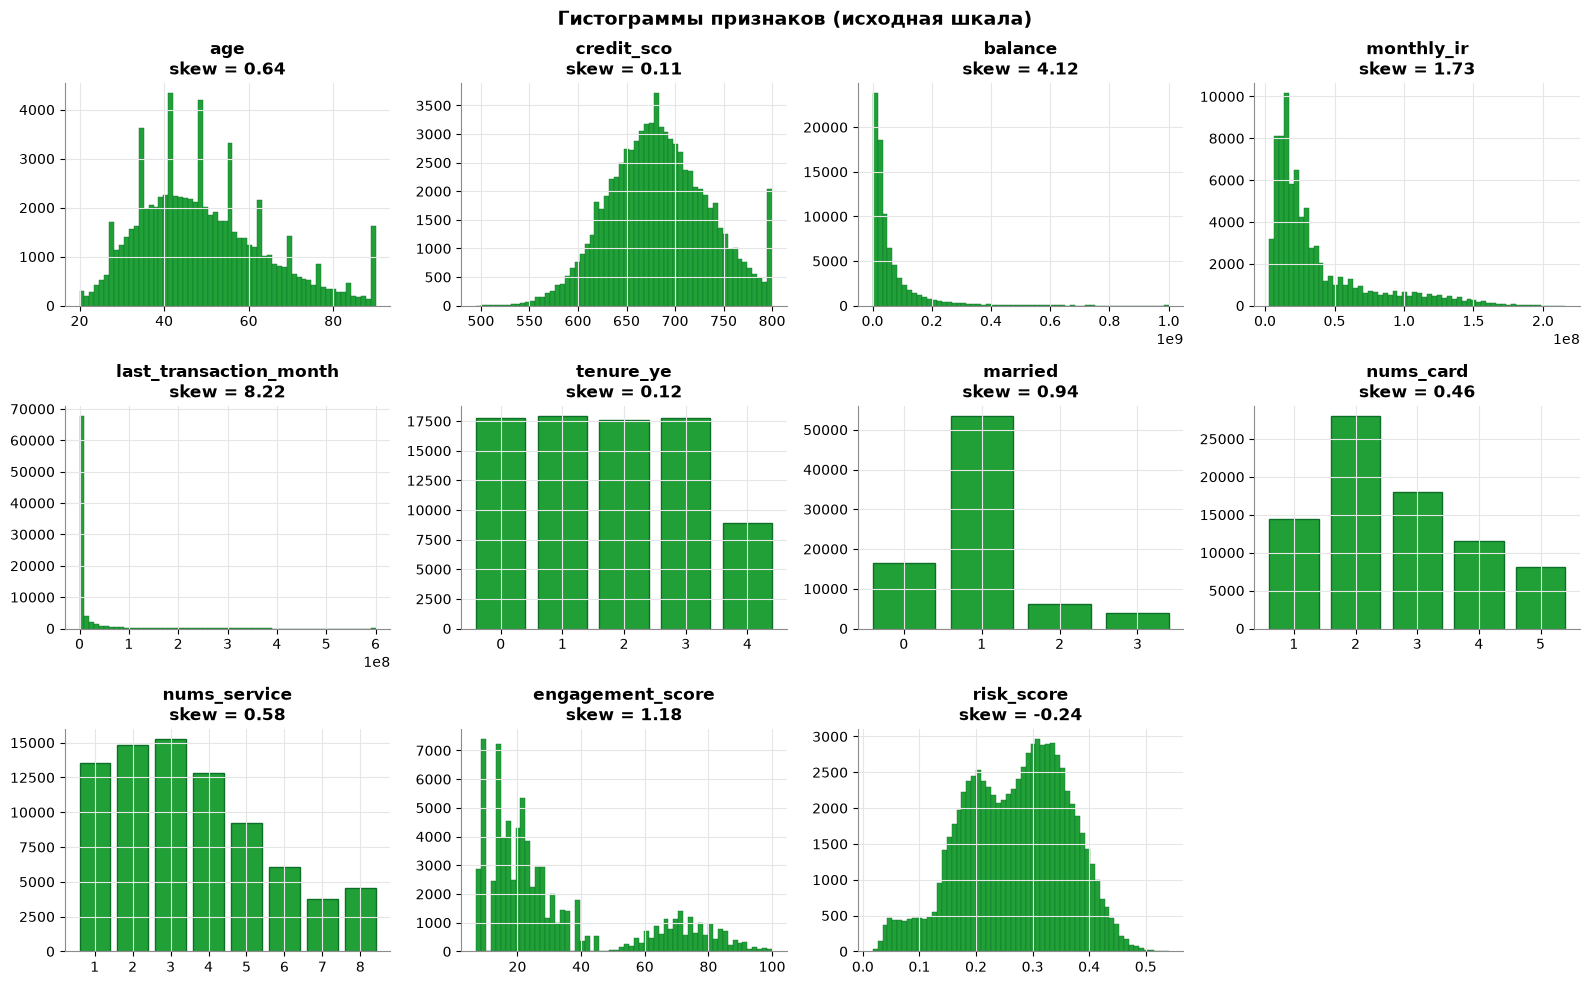

In [7]:
num_cols = ["age", "credit_sco", "balance", "monthly_ir", "last_transaction_month",
            "tenure_ye", "married", "nums_card", "nums_service", "engagement_score", "risk_score"]

hist_subplots(df, num_cols)
plt.show()

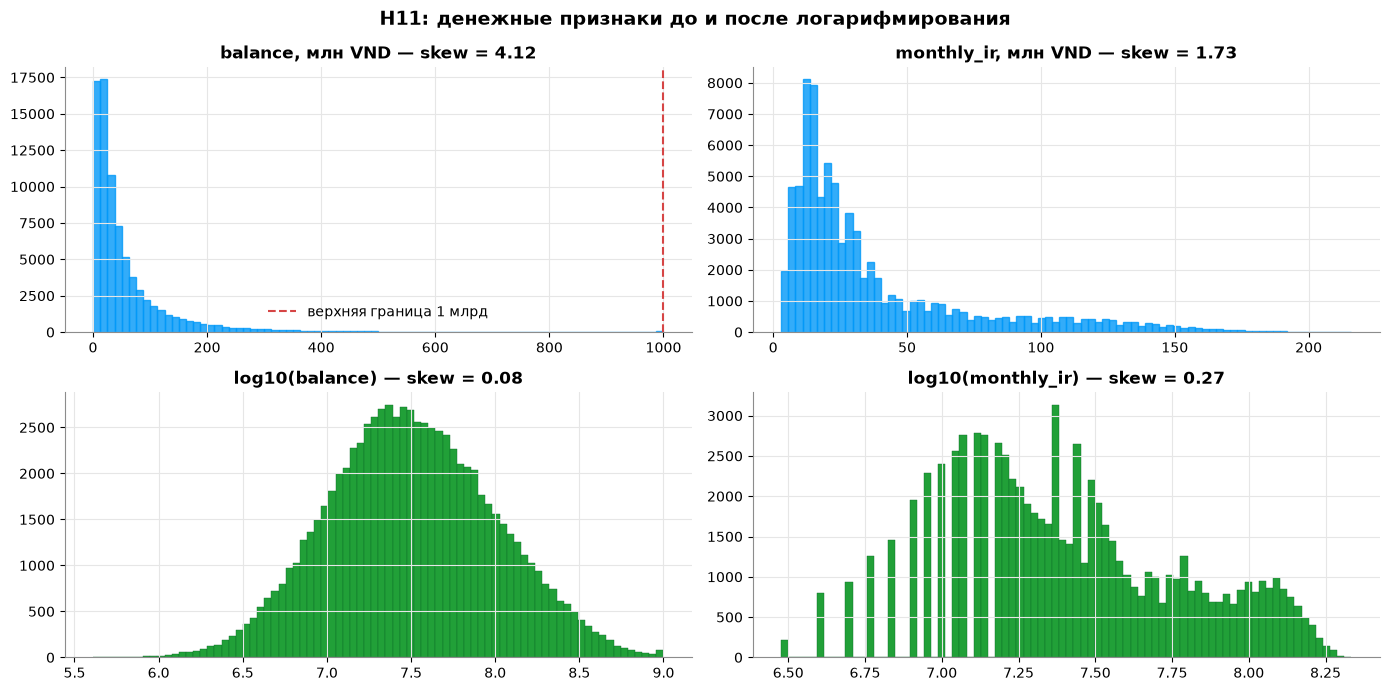

In [8]:
money = ["balance", "monthly_ir"]
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for i, col in enumerate(money):
    axes[0, i].hist(df[col] / MLN, bins=80, color=BLUE, edgecolor=BLUE, alpha=0.8)
    axes[0, i].set_title(f"{col}, млн VND — skew = {df[col].skew():.2f}")
    axes[1, i].hist(np.log10(df[col]), bins=80, color=GREEN, edgecolor=GREEN_DARK, linewidth=0.3)
    axes[1, i].set_title(f"log10({col}) — skew = {np.log10(df[col]).skew():.2f}")
axes[0, 0].axvline(1000, color=ERROR_RED, ls="--", label="верхняя граница 1 млрд")
axes[0, 0].legend()
fig.suptitle("H11: денежные признаки до и после логарифмирования", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**H11 подтверждается.** `balance`, `monthly_ir` и `last_transaction_month` сильно скошены вправо (skew 2–5):
в евклидовом пространстве горстка самых богатых клиентов доминировала бы над остальными. После `log10`
распределение log10(balance) становятся почти симметричными. `last_transaction_month` на ~79 % состоит из нулей — это не непрерывный
признак, а «признак активности × сумма», его разберём в H3. `age`, `tenure_ye`, `credit_sco` распределены
ровно, без выбросов — их достаточно стандартизовать.

### 4.2 H1 — сегмент клиента определяется доходом

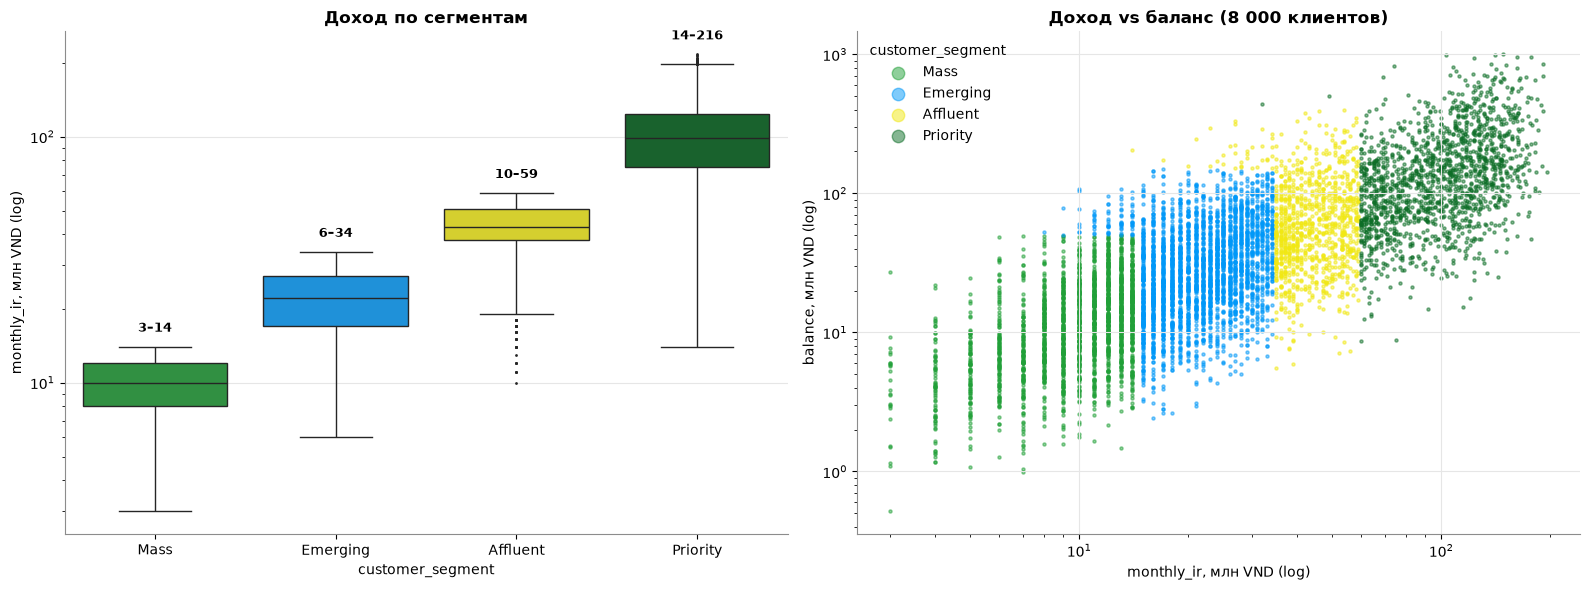

Точность дерева глубины 4 (доход, баланс, рейтинг) -> customer_segment: 1.0000
Важности признаков [доход, баланс, рейтинг]: [0.96 0.04 0.  ]


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
seg_colors = {s: category_color(i) for i, s in enumerate(SEGMENT_ORDER)}

sns.boxplot(
    data=df, x="customer_segment", 
    y=df["monthly_ir"] / MLN, order=SEGMENT_ORDER,
    palette=seg_colors, ax=axes[0], fliersize=1
)
axes[0].set_yscale("log")
axes[0].set_ylabel("monthly_ir, млн VND (log)")
axes[0].set_title("Доход по сегментам")
rng = df.groupby("customer_segment")["monthly_ir"].agg(
    ["min", "max"]
).loc[SEGMENT_ORDER] / MLN
for i, (lo, hi) in enumerate(rng.values):
    axes[0].text(
        i, hi * 1.15, f"{lo:.0f}–{hi:.0f}", 
        ha="center", fontsize=9, fontweight="bold"
    )

sample = df.sample(8000, random_state=RANDOM_STATE)
for s in SEGMENT_ORDER:
    part = sample[sample["customer_segment"] == s]
    axes[1].scatter(
        part["monthly_ir"] / MLN, 
        part["balance"] / MLN, 
        s=5, alpha=0.5,
        color=seg_colors[s], label=s
    )
axes[1].set_xscale("log") 
axes[1].set_yscale("log")
axes[1].set_xlabel("monthly_ir, млн VND (log)") 
axes[1].set_ylabel("balance, млн VND (log)")
axes[1].set_title("Доход vs баланс (8 000 клиентов)")
axes[1].legend(markerscale=4, title="customer_segment")
fig.tight_layout()
plt.show()

tree = DecisionTreeClassifier(
    max_depth=4, random_state=RANDOM_STATE
)
Xs = np.column_stack([
    np.log(df["monthly_ir"]), 
    np.log(df["balance"]), 
    df["credit_sco"]
])
tree.fit(Xs, df["customer_segment"])
print(f"Точность дерева глубины 4 (доход, баланс, рейтинг) -> customer_segment: {tree.score(Xs, df['customer_segment']):.4f}")
print("Важности признаков [доход, баланс, рейтинг]:", tree.feature_importances_.round(3))

**H1 подтверждается частично.** Сегменты — это вложенные диапазоны дохода (Mass 3–14, Emerging 6–34,
Affluent 10–59, Priority 14–216 млн VND/мес.) с перекрытием, которое снимается балансом: простое дерево глубины 4 по доходу,
балансу и рейтингу восстанавливает сегмент на 100 %, причём 96 % важности приходится на доход. Значит, `customer_segment` — это **детерминированное
правило** поверх `monthly_ir`/`balance`; в модель его подавать нельзя (он удвоит вес финансовых признаков), но он
очень удобен для интерпретации кластеров. Доход и баланс сильно связаны, но облако широкое: при одинаковом доходе
баланс различается на порядок — отсюда идея признака «баланс / доход» (сколько месячных доходов лежит на счёте).

### 4.3 H2 — доход и баланс определяются профессией

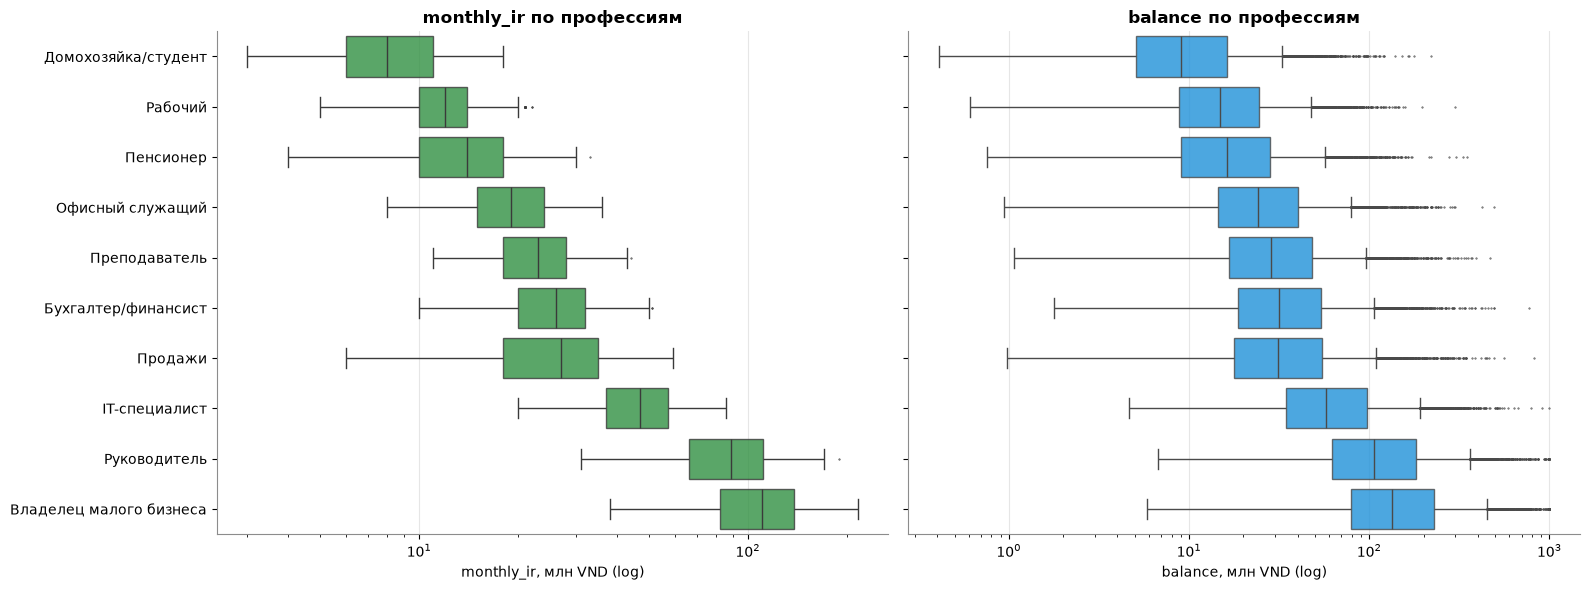

Возраст по профессиям практически одинаков:
 occupation_ru  IT-специалист  Бухгалтер/финансист  Владелец малого бизнеса  Домохозяйка/студент  Офисный служащий  Пенсионер  Преподаватель  Продажи  Рабочий  Руководитель
mean                    49.2                 49.6                     49.2                 49.6              49.5       49.2           49.6     49.2     49.3          49.4
std                     15.1                 15.2                     15.1                 15.2              15.1       14.9           15.2     15.0     14.7          15.2


In [10]:
order = df.groupby("occupation_ru")["monthly_ir"].median().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, col, color in [(axes[0], "monthly_ir", GREEN), (axes[1], "balance", BLUE)]:
    sns.boxplot(data=df, y="occupation_ru", x=df[col] / MLN, order=order, color=color, ax=ax,
                fliersize=0.5, boxprops=dict(alpha=0.8))
    ax.set_xscale("log"); ax.set_xlabel(f"{col}, млн VND (log)"); ax.set_ylabel("")
    ax.set_title(f"{col} по профессиям")
fig.tight_layout()
plt.show()

occ_age = df.groupby("occupation_ru")["age"].agg(["mean", "std"]).round(1)
print("Возраст по профессиям практически одинаков:\n", occ_age.T)

**H2 подтверждается.** Медианный доход отличается больше чем на порядок: от ~8 млн (домохозяйки/студенты) до ~110 млн
(владельцы малого бизнеса). Профессия — главный «генератор» дохода, а значит информация о ней уже содержится в
`monthly_ir`. Отдельно подавать one-hot из 10 профессий в модель не будем: это 10 бинарных осей, которые захватят
геометрию пространства; профессию используем для описания кластеров.

### 4.4 H3 — все признаки активности описывают одно и то же

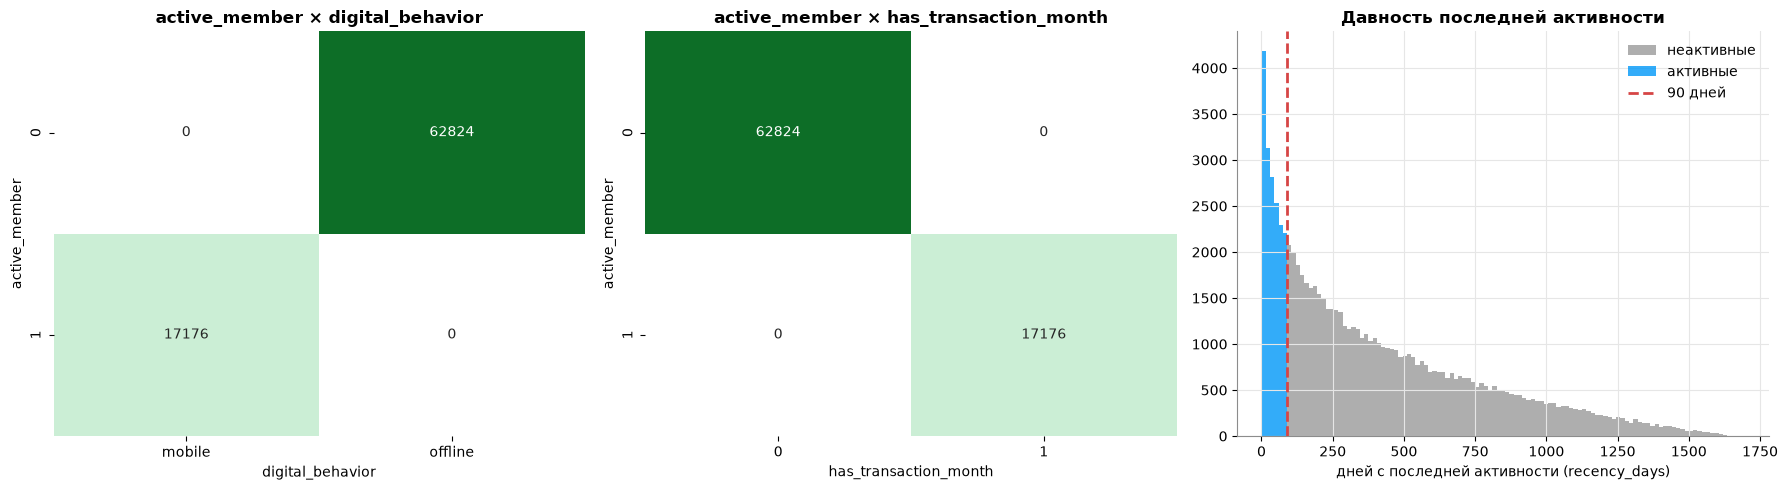

max recency у активных: 89 | min recency у неактивных: 90


In [11]:
df["recency_days"] = (REF_DATE - df["last_active_date"]).dt.days
df["has_transaction_month"] = (df["last_transaction_month"] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ct1 = pd.crosstab(df["active_member"], df["digital_behavior"])
ct2 = pd.crosstab(df["active_member"], df["has_transaction_month"])
for iter_ax, iter_ct in zip(axes, [ct1, ct2]):
      sns.heatmap(
            iter_ct, annot=True, fmt="d", 
            cmap=SEQUENTIAL_CMAP, cbar=False, 
            ax=iter_ax
      )
      title = f"{iter_ct.index.name} × {iter_ct.columns.name}"
      iter_ax.set_title(title)
      iter_ax.grid(False)


bins = np.arange(0, 1700, 15)
axes[2].hist(
    df.loc[df.active_member == 0, "recency_days"], 
    bins=bins, color=INACTIVE_COLOR, 
    alpha=0.7, label="неактивные"
)
axes[2].hist(
    df.loc[df.active_member == 1, "recency_days"], 
    bins=bins, color=ACTIVE_COLOR, 
    alpha=0.8, label="активные"
)
axes[2].axvline(
    90, color=ERROR_RED, ls="--", 
    lw=2, label="90 дней"
)
axes[2].set_xlabel("дней с последней активности (recency_days)")
axes[2].set_title("Давность последней активности")
axes[2].legend()
fig.tight_layout()
plt.show()

print(
    "max recency у активных:", df.loc[df.active_member == 1, "recency_days"].max(),
    "| min recency у неактивных:", df.loc[df.active_member == 0, "recency_days"].min()
)

**H3 подтверждается полностью.** Четыре колонки кодируют один факт:
`active_member = 1` ⇔ `digital_behavior = mobile` ⇔ `last_transaction_month > 0` ⇔ `recency_days < 90`.
Поэтому бинарные `active_member` и `digital_behavior` дублируют друг друга; в модели оставим **непрерывную**
давность активности `recency_days` (она содержит порог 90 дней и больше информации), а сумму транзакций
нормируем на доход (`tn_to_income`), чтобы отличать «активных с крупными оборотами» от «активных с мелкими».

### 4.5 H4 и H5 — стаж и лояльность

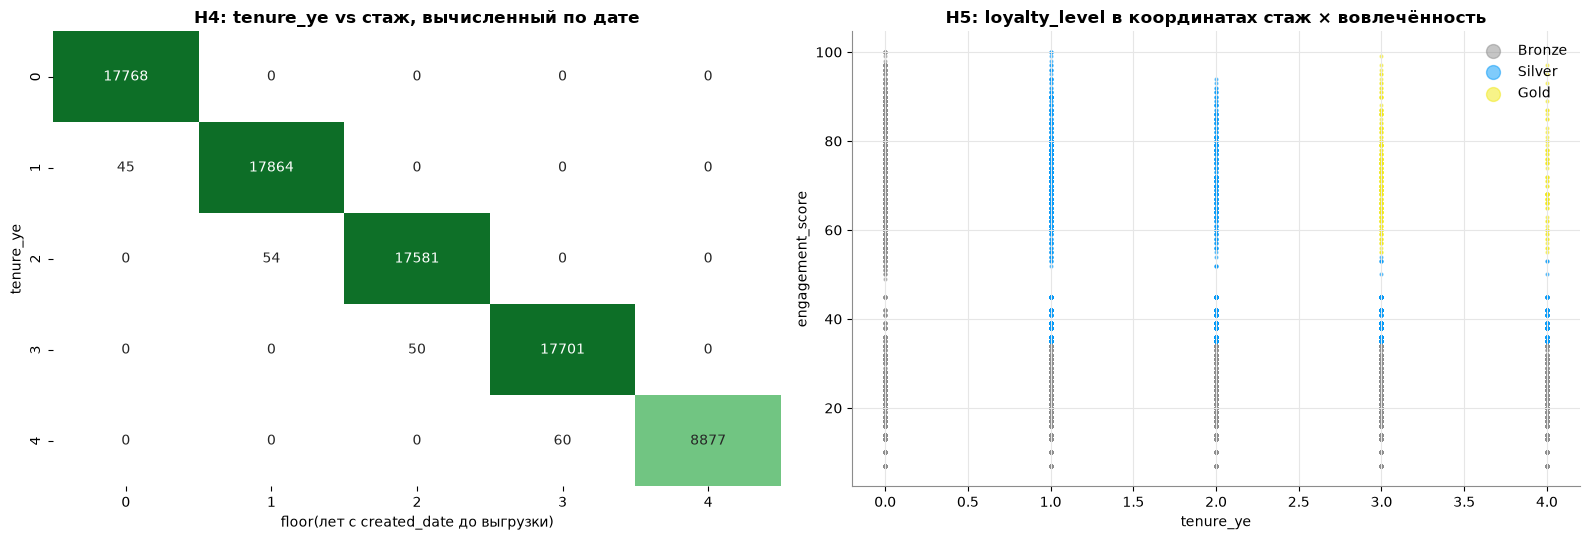

Совпадение tenure_ye с вычисленным стажем: 99.74%
Дерево по (tenure_ye, engagement_score) восстанавливает loyalty_level с точностью 1.0000
               tenure_ye  engagement_score
loyalty_level                             
Bronze                 0                 7
Silver                 1                35
Gold                   3                55


In [12]:
df["account_age_days"] = (REF_DATE - df["created_date"]).dt.days
df["tenure_calc"] = np.floor(df["account_age_days"] / 365.25).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(
    pd.crosstab(df["tenure_ye"], df["tenure_calc"]), 
    annot=True, fmt="d", cmap=SEQUENTIAL_CMAP, cbar=False, ax=axes[0]
)
axes[0].set_xlabel("floor(лет с created_date до выгрузки)")
axes[0].set_title("H4: tenure_ye vs стаж, вычисленный по дате")
axes[0].grid(False)

rng_ = np.random.default_rng(RANDOM_STATE)
smp = df.sample(12000, random_state=RANDOM_STATE)
for i, lvl in enumerate(LOYALTY_ORDER):
    part = smp[smp["loyalty_level"] == lvl]
    axes[1].scatter(
        part["tenure_ye"], 
        part["engagement_score"],
        s=4, alpha=0.5, 
        color=[GRAY, BLUE, YELLOW][i], label=lvl
    )
axes[1].set_xlabel("tenure_ye")
axes[1].set_ylabel("engagement_score")
axes[1].set_title("H5: loyalty_level в координатах стаж × вовлечённость")
axes[1].legend(markerscale=5)
fig.tight_layout()
plt.show()

match = (df["tenure_ye"] == df["tenure_calc"]).mean()
print(f"Совпадение tenure_ye с вычисленным стажем: {match:.2%}")
Xl = df[["tenure_ye", "engagement_score"]]
t = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE).fit(Xl, df["loyalty_level"])
print(f"Дерево по (tenure_ye, engagement_score) восстанавливает loyalty_level с точностью {t.score(Xl, df['loyalty_level']):.4f}")
print(df.groupby("loyalty_level")[["tenure_ye", "engagement_score"]].min().loc[LOYALTY_ORDER])

**H4 подтверждается:** `tenure_ye` — это округлённый вниз возраст счёта. 
Вместо дискретного `tenure_ye` в модели используем непрерывный `account_age_days` → в месяцах.

**H5 подтверждается:** `loyalty_level` задаётся порогами — Gold: стаж ≥ 3 и вовлечённость ≥ 55, Silver: стаж ≥ 1 и
вовлечённость ≥ 35, остальные Bronze. Признак полностью производный → только для интерпретации.

### 4.6 H6 — `engagement_score` и `risk_score` — производные признаки

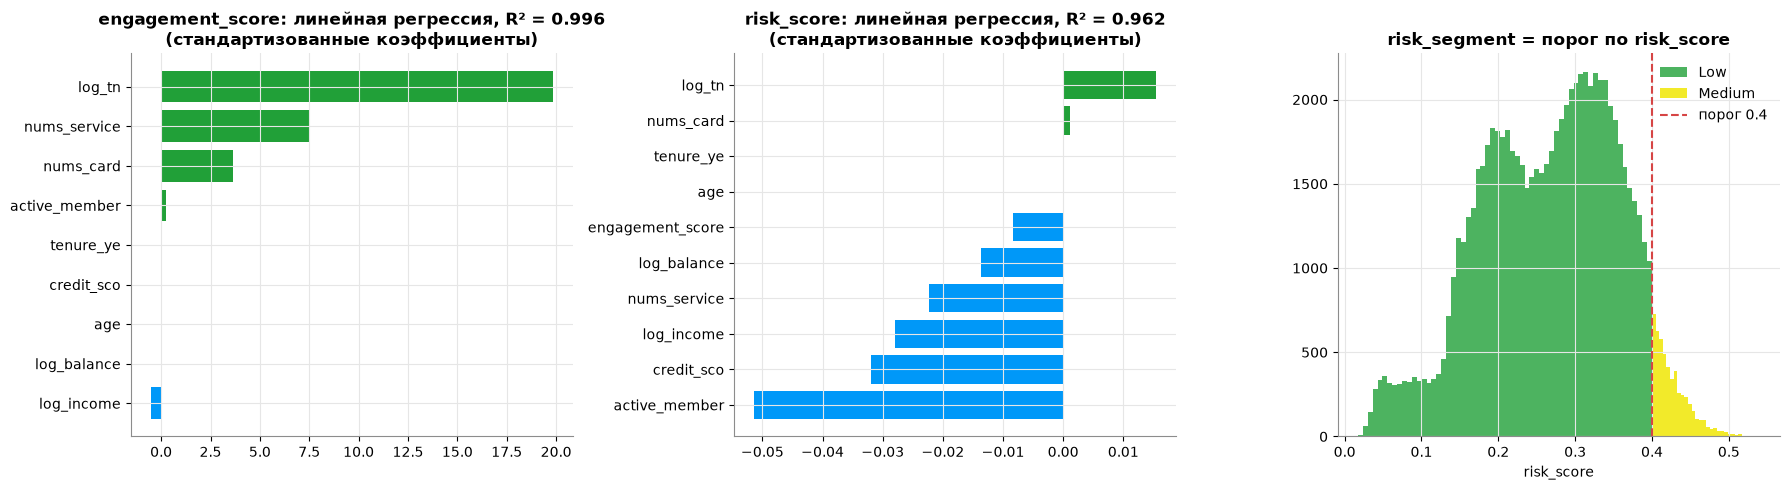

In [13]:
base = pd.DataFrame({
    "log_income": np.log(df["monthly_ir"]),
    "log_balance": np.log(df["balance"]),
    "credit_sco": df["credit_sco"],
    "age": df["age"],
    "tenure_ye": df["tenure_ye"],
    "nums_card": df["nums_card"],
    "nums_service": df["nums_service"],
    "active_member": df["active_member"],
    "log_tn": np.log1p(df["last_transaction_month"]),
})
r2 = {}
for target, X_ in [
    ("engagement_score", base), 
    ("risk_score", base.assign(engagement_score=df["engagement_score"]))
    ]:
    lr = LinearRegression().fit(X_, df[target])
    r2[target] = lr.score(X_, df[target])
    coefs = pd.Series(lr.coef_ * X_.std().values, index=X_.columns)  # стандартизованные коэффициенты
    r2[target + "_coefs"] = coefs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, target in zip(axes[:2], ["engagement_score", "risk_score"]):
    c = r2[target + "_coefs"].sort_values()
    ax.barh(
        c.index, c.values, 
        color=[GREEN if v > 0 else BLUE for v in c.values]
    )
    ax.set_title(f"{target}: линейная регрессия, R² = {r2[target]:.3f}\n(стандартизованные коэффициенты)")
axes[2].hist(
    df.loc[df.risk_segment == "Low", "risk_score"], 
    bins=60, color=GREEN, alpha=0.8, label="Low"
)
axes[2].hist(
    df.loc[df.risk_segment == "Medium", "risk_score"], 
    bins=30, color=YELLOW, alpha=0.9, label="Medium"
)
axes[2].axvline(0.4, color=ERROR_RED, ls="--", label="порог 0.4")
axes[2].set_title("risk_segment = порог по risk_score")
axes[2].set_xlabel("risk_score")
axes[2].legend()
fig.tight_layout()
plt.show()

**H6 подтверждается.** Обычная линейная регрессия по исходным признакам объясняет **99,6 %** дисперсии
`engagement_score` (главные вклады — число услуг, активность, число карт) и **~96 %** дисперсии `risk_score`
(доход, рейтинг, вовлечённость). `risk_segment` — порог `risk_score ≥ 0.4`. Добавлять такие признаки в модель —
значит повторно подавать те же сигналы с другим весом. Исключаем их из модели, используем при интерпретации.

### 4.7 H7 — от чего зависит отток

`exit` в модель не подаём, но проверим, какие признаки с ним связаны: хорошая сегментация должна «разводить»
клиентов с разным риском ухода, и эти графики станут эталоном для проверки кластеров в ноутбуке 05.

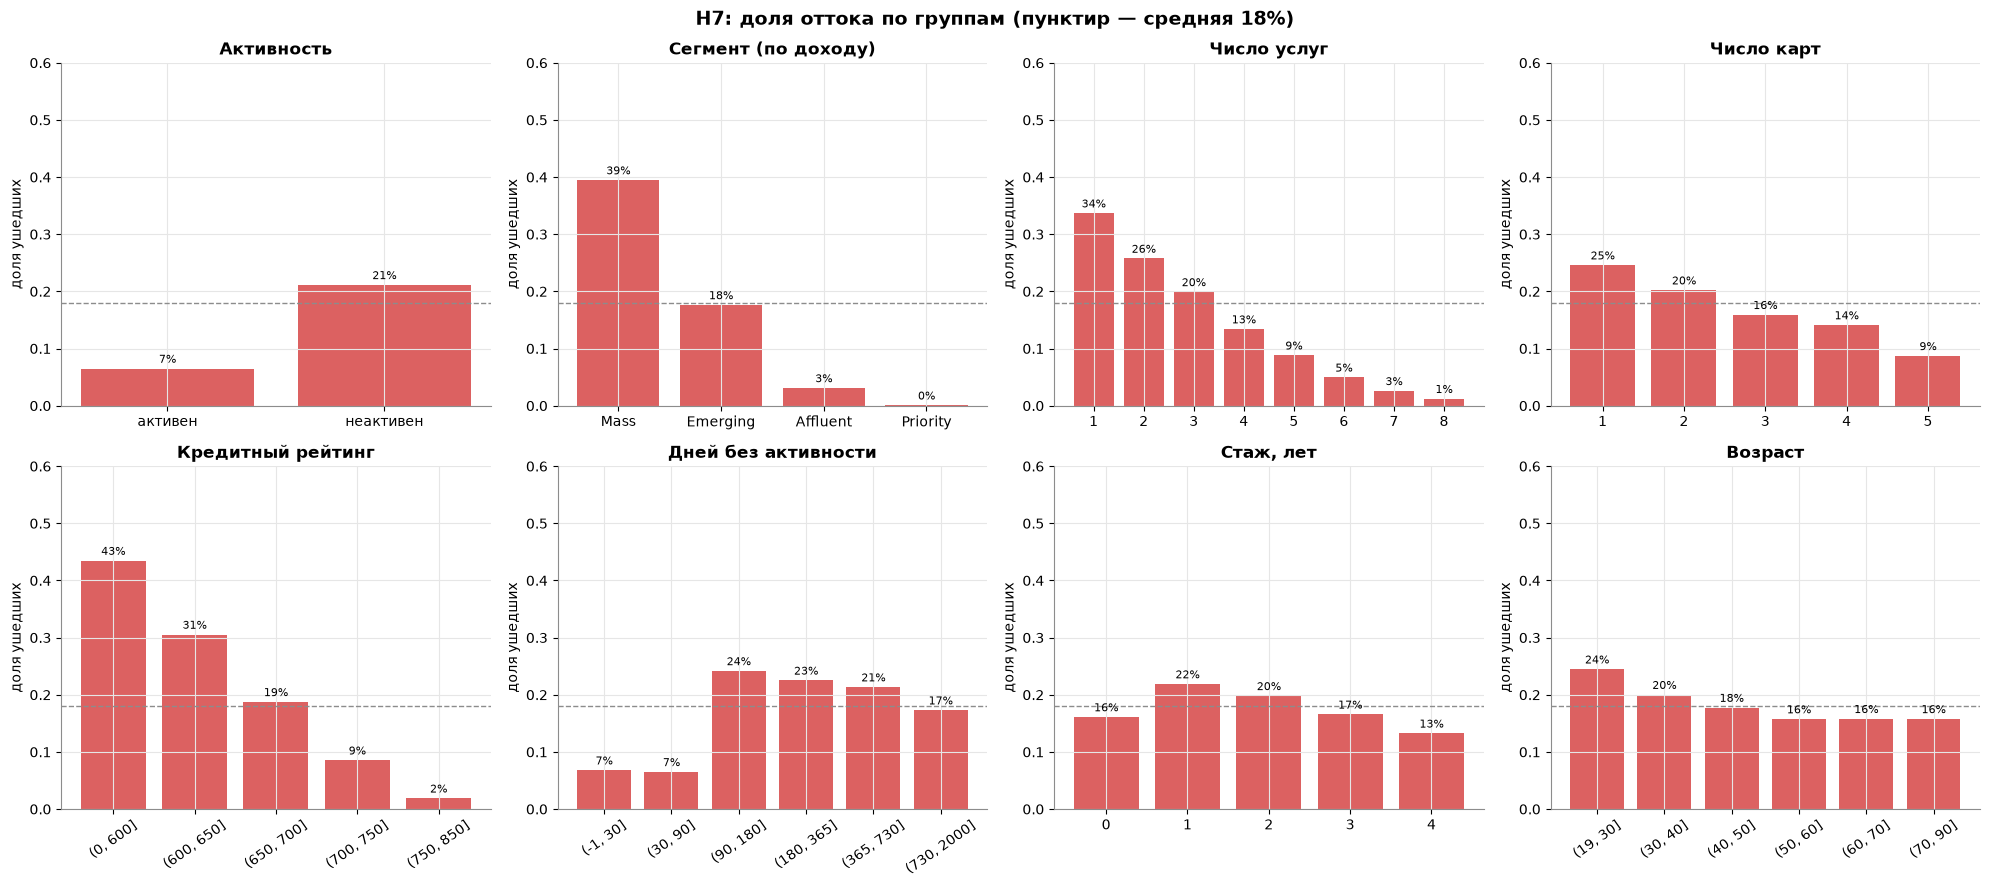

In [14]:
def churn_rate_plot(ax, series, title, order=None, rotate=False):
    rate = df.groupby(series)["exit"].agg(["mean", "size"])
    if order is not None:
        rate = rate.loc[order]
    ax.bar(rate.index.astype(str), rate["mean"], color=CHURN_COLOR, alpha=0.85)
    ax.axhline(df["exit"].mean(), color=GRAY, ls="--", lw=1)
    for i, (m, n) in enumerate(rate.values):
        ax.text(i, m + 0.01, f"{m:.0%}", ha="center", fontsize=8)
    ax.set_title(title); ax.set_ylabel("доля ушедших")
    ax.set_ylim(0, max(0.6, rate["mean"].max() + 0.08))
    if rotate:
        ax.tick_params(axis="x", rotation=35)


fig, axes = plt.subplots(2, 4, figsize=(20, 9))
churn_rate_plot(axes[0, 0], df["active_member"].map({0: "неактивен", 1: "активен"}), "Активность")
churn_rate_plot(axes[0, 1], df["customer_segment"], "Сегмент (по доходу)", order=SEGMENT_ORDER)
churn_rate_plot(axes[0, 2], df["nums_service"], "Число услуг")
churn_rate_plot(axes[0, 3], df["nums_card"], "Число карт")
churn_rate_plot(axes[1, 0], pd.cut(df["credit_sco"], [0, 600, 650, 700, 750, 850]), "Кредитный рейтинг", rotate=True)
churn_rate_plot(axes[1, 1], pd.cut(df["recency_days"], [-1, 30, 90, 180, 365, 730, 2000]), "Дней без активности", rotate=True)
churn_rate_plot(axes[1, 2], df["tenure_ye"], "Стаж, лет")
churn_rate_plot(axes[1, 3], pd.cut(df["age"], [19, 30, 40, 50, 60, 70, 90]), "Возраст", rotate=True)
fig.suptitle(f"H7: доля оттока по группам (пунктир — средняя {df['exit'].mean():.0%})", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**H7 подтверждается.** Сильнее всего отток связан с **доходом** (Mass — ~39 %, Priority — практически 0 %),
**активностью** (неактивные уходят в ~3 раза чаще), **числом услуг** и **кредитным рейтингом**. Интересно, что риск
максимален не у давно «уснувших», а у клиентов, которые перестали быть активными 3–12 месяцев назад: уход
фиксируется вскоре после прекращения активности. Стаж и возраст влияют слабо (у клиентов до 30 лет отток чуть выше — 24 %).

### 4.8 H8 и H9 — демографические признаки

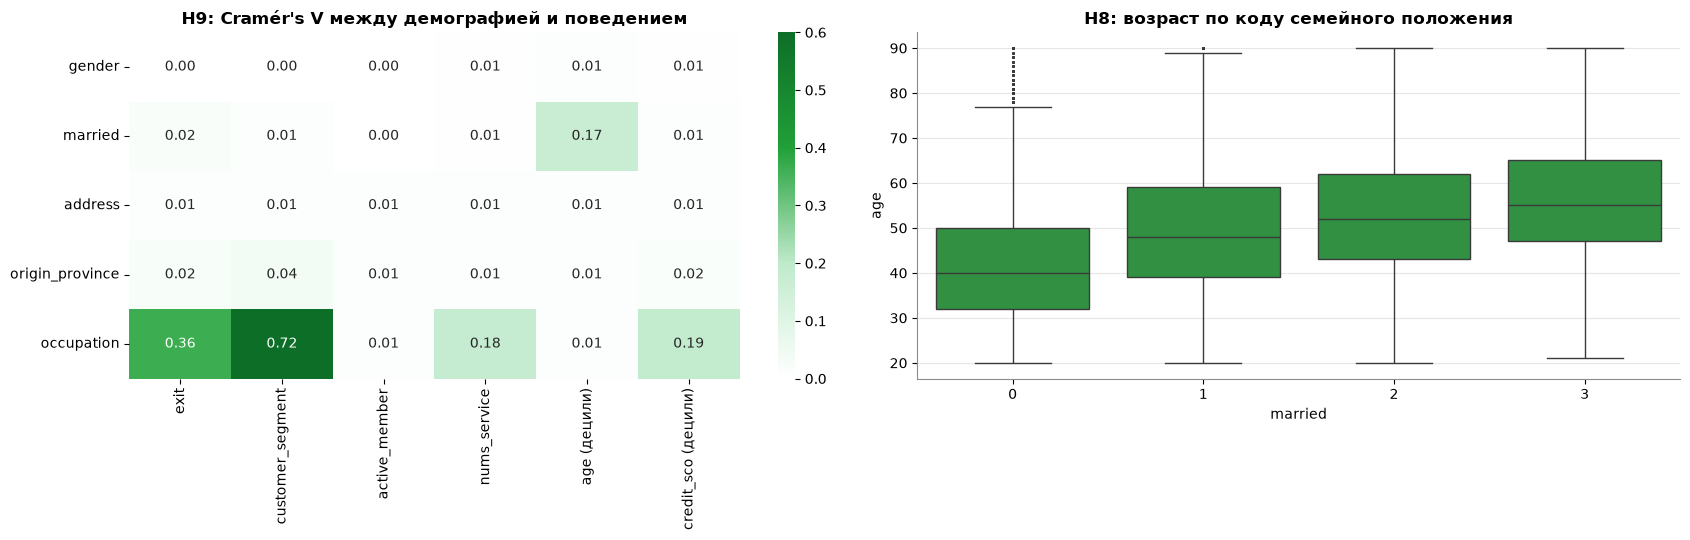

In [15]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


demo = ["gender", "married", "address", "origin_province", "occupation"]
refs = {
    "exit": df["exit"],
    "customer_segment": df["customer_segment"],
    "active_member": df["active_member"],
    "nums_service": df["nums_service"],
    "age (децили)": pd.qcut(df["age"], 10),
    "credit_sco (децили)": pd.qcut(df["credit_sco"], 10),
}
cv = pd.DataFrame(
    {r: [cramers_v(df[d], v) for d in demo] for r, v in refs.items()}, 
    index=demo
)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
sns.heatmap(
    cv, annot=True, fmt=".2f", cmap=SEQUENTIAL_CMAP, 
    vmin=0, vmax=0.6, ax=axes[0]
)
axes[0].set_title("H9: Cramér's V между демографией и поведением")
sns.boxplot(
    data=df, x="married", y="age", 
    color=GREEN, ax=axes[1], fliersize=0.5
)
axes[0].grid(False)
axes[1].set_title("H8: возраст по коду семейного положения")
fig.tight_layout()
plt.show()

**H8 подтверждается:** медианный возраст растёт с кодом `married` (0 → 40 лет, 3 → 55 лет), что может согласоваться с
кодировкой «не в браке / в браке / разведён / вдовец».

**H9 подтверждается:** `gender`, `address`, `origin_province` практически независимы и от оттока, и от финансов,
и от активности (Cramér's V ≈ 0). Для кластеризации это чистый шум — такие признаки только добавят к расстояниям
случайную составляющую. `occupation` сильно связана с сегментом (V ≈ 0,72) и с оттоком (V ≈ 0,36), но, как показано в H2,
эта связь проходит через доход: профессия задаёт доход, доход задаёт сегмент и риск ухода. Демографию сохраняем для профилирования кластеров, в модель не подаём.

### 4.9 H10 — что такое `cluster_group`

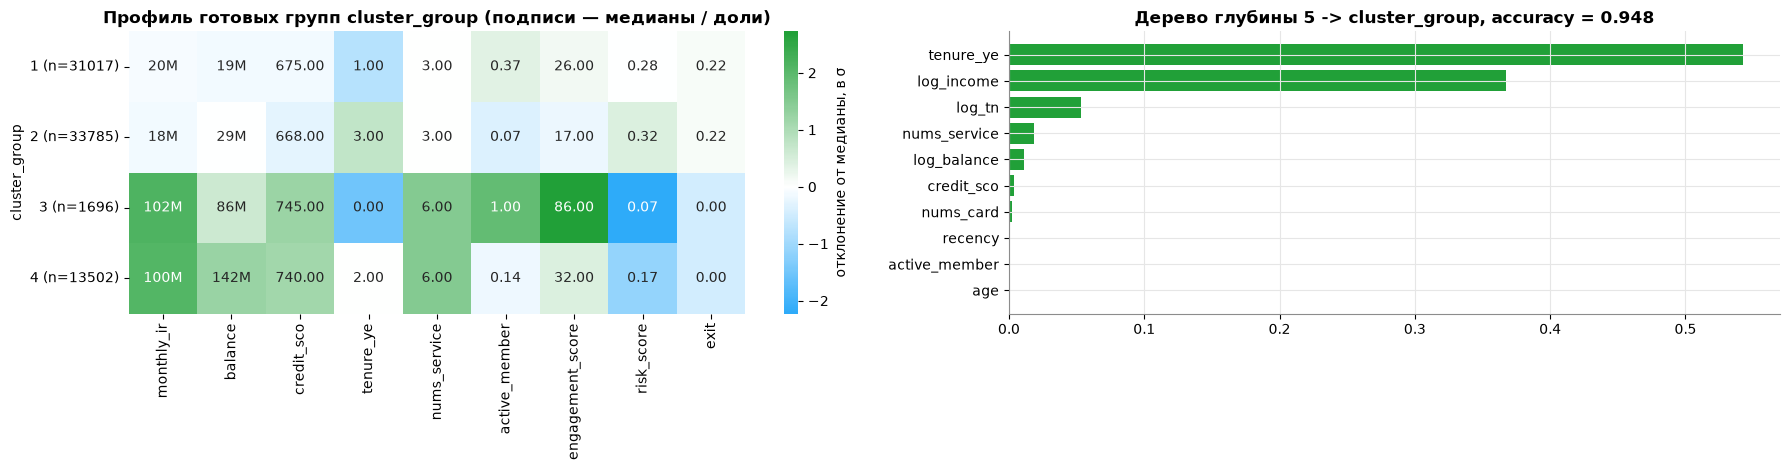

In [16]:
prof_cols = [
    "monthly_ir", "balance", "credit_sco", 
    "tenure_ye", "nums_service", "active_member",
    "engagement_score", "risk_score", "exit"
]
cg_df = df.groupby("cluster_group")[prof_cols].median()
cg_df["active_member"] = df.groupby("cluster_group")["active_member"].mean()
cg_df["exit"] = df.groupby("cluster_group")["exit"].mean()
cg_df["size"] = df["cluster_group"].value_counts()
z_score = (cg_df[prof_cols] - df[prof_cols].median()) / df[prof_cols].std()
z_score["exit"] = (cg_df["exit"] - df["exit"].mean()) / df["exit"].std()
z_score["active_member"] = (cg_df["active_member"] - df["active_member"].mean()) / df["active_member"].std()

Xc = base.assign(recency=df["recency_days"])
cluster_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE).fit(Xc, df["cluster_group"])
imp = pd.Series(cluster_tree.feature_importances_, index=Xc.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 4.8))
sns.heatmap(
    z_score, fmt="",
    annot=cg_df[prof_cols].map(lambda v: f"{v/MLN:.0f}M" if v > 1e5 else f"{v:.2f}"),
    cmap=DIVERGING_CMAP, center=0, 
    ax=axes[0], cbar_kws={"label": "отклонение от медианы, в σ"}
)
axes[0].set_yticklabels(
    [f"{i} (n={n})" for i, n in cg_df["size"].items()],
    rotation=0
)
axes[0].set_title("Профиль готовых групп cluster_group (подписи — медианы / доли)")
axes[0].grid(False)
axes[1].barh(imp.index, imp.values, color=GREEN)
axes[1].set_title(
    f"Дерево глубины 5 -> cluster_group, accuracy = {cluster_tree.score(Xc, df['cluster_group']):.3f}"
)
fig.tight_layout()
plt.show()

**H10 подтверждается.** `cluster_group` — готовая сегментация банка: дерево по исходным признакам восстанавливает
её на ~95 %, основные оси — стаж и доход, немного активность. Группы 3 и 4 — состоятельные клиенты без оттока
(3 — новые и очень активные, 4 — со стажем ~2 года), 1 и 2 — массовые клиенты с оттоком ~22 %
(1 — стаж около года, 2 — «старые» и почти неактивные). В модель её не подаём (это ответ другой модели), но используем как **внешний
эталон**: в ноутбуке 05 сравним наши кластеры с ней через ARI / NMI.

### 4.10 Сводная матрица корреляций

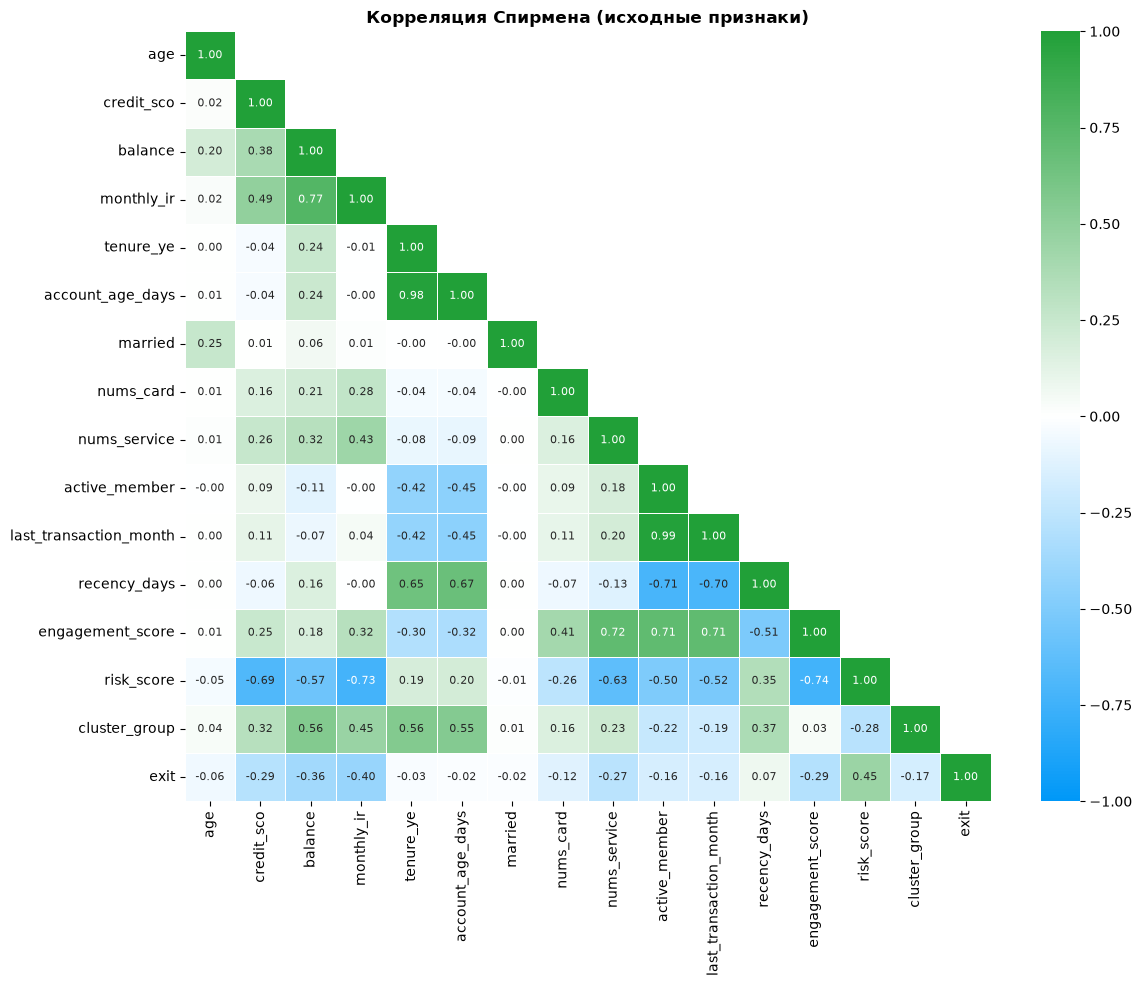

In [17]:
corr_cols = ["age", "credit_sco", "balance", "monthly_ir", "tenure_ye", "account_age_days", "married",
             "nums_card", "nums_service", "active_member", "last_transaction_month", "recency_days",
             "engagement_score", "risk_score", "cluster_group", "exit"]
corr = df[corr_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 8}, linewidths=0.5, linecolor="white")
ax.set_title("Корреляция Спирмена (исходные признаки)")
ax.grid(False)
plt.show()

Картина согласуется с гипотезами: блок «финансы» (`balance`, `monthly_ir`, `credit_sco`, `risk_score`),
блок «активность» (`active_member`, `last_transaction_month`, `recency_days`, `engagement_score`),
дубли `tenure_ye` ≈ `account_age_days` (ρ ≈ 1) и `active_member` ≈ `last_transaction_month` (ρ ≈ 0,99).
Возраст и семейное положение живут отдельно от всего остального.

### Итог анализа

| Решение | Колонки | Обоснование |
|---|---|---|
| Удалить | `id`, `full_name`, `address` | идентификаторы / персональные данные |
| Только для интерпретации (производные) | `customer_segment`, `loyalty_level`, `engagement_score`, `risk_score`, `risk_segment` | H1, H5, H6 — правила над исходными колонками |
| Только для валидации (внешние метки) | `exit`, `cluster_group` | цель задачи оттока и чужая сегментация |
| Только для интерпретации (шум для модели) | `gender`, `origin_province`, `married`, `occupation` | H2, H8, H9 |
| Заменить непрерывными аналогами | `active_member`, `digital_behavior` → `recency_days`; `tenure_ye` → `account_age_months` | H3, H4 |
| Преобразовать | `balance`, `monthly_ir`, `last_transaction_month` | H11 — логарифм и отношения |
| Оставить | `age`, `credit_sco`, `nums_card`, `nums_service` | исходные, не дублируются |

## 5. Подготовка данных

### 5.1 Очистка и заполнение пропусков

Пропусков нет, заполнять нечего. Очистка сводится к:
* приведению типов (даты, bool → int) — сделано при загрузке;
* пометке цензурированного баланса (`balance_capped`) — 50 строк не удаляем, логарифм и винсоризация сгладят их влияние;
* удалению идентификаторов и персональных данных.

### 5.2 Конструирование признаков

| Признак | Формула | Смысл |
|---|---|---|
| `log_income` | ln(`monthly_ir`) | уровень дохода — главная ось благосостояния |
| `log_savings_ratio` | ln(`balance` / `monthly_ir`) | «подушка»: сколько месячных доходов лежит на счёте. Отделяет «копящих» от «тратящих» при одинаковом доходе и декоррелирует пару доход–баланс |
| `credit_sco` | как есть | кредитная надёжность |
| `age` | как есть | стадия жизненного цикла |
| `account_age_months` | (REF_DATE − `created_date`) / 30.44 | стаж в непрерывной шкале |
| `nums_card`, `nums_service` | как есть | глубина продуктовых отношений |
| `sqrt_recency` | √(дней с последней активности) | давность активности; порог активности (90 дней) остаётся внутри шкалы. Корень, а не логарифм: у `recency_days` умеренная правая асимметрия (skew ≈ 1), логарифм «перегибает» её в длинный левый хвост (skew ≈ −1.2), корень даёт почти симметричное распределение (skew ≈ 0.2) |
| `tn_to_income` | ln(1 + `last_transaction_month` / `monthly_ir`) | оборот за последний месяц в «месячных доходах»; 0 у неактивных |

In [18]:
def build_features(data: pd.DataFrame, ref_date: pd.Timestamp) -> pd.DataFrame:
    # Конструирование признаков-кандидатов из исходных колонок (без утечки: только исходные поля).
    out = pd.DataFrame(index=data.index)
    out["log_income"] = np.log(data["monthly_ir"])
    out["log_balance"] = np.log(data["balance"])
    out["log_savings_ratio"] = np.log(data["balance"] / data["monthly_ir"])
    out["credit_sco"] = data["credit_sco"].astype(float)
    out["age"] = data["age"].astype(float)
    out["account_age_months"] = (ref_date - data["created_date"]).dt.days / 30.44
    out["tenure_ye"] = data["tenure_ye"].astype(float)
    out["nums_card"] = data["nums_card"].astype(float)
    out["nums_service"] = data["nums_service"].astype(float)
    out["products_total"] = out["nums_card"] + out["nums_service"]
    out["recency_days"] = (ref_date - data["last_active_date"]).dt.days.astype(float)
    out["log_recency"] = np.log1p(out["recency_days"])
    out["sqrt_recency"] = np.sqrt(out["recency_days"])
    out["active_member"] = data["active_member"].astype(float)
    out["log_tn"] = np.log1p(data["last_transaction_month"])
    out["tn_to_income"] = np.log1p(data["last_transaction_month"] / data["monthly_ir"])
    out["married"] = data["married"].astype(float)
    return out

candidates = build_features(df, REF_DATE)
df["balance_capped"] = (df["balance"] >= 1e9).astype(int)
candidates.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
log_income,80000.0,17.06,0.87,14.91,16.45,16.95,17.67,19.19
log_balance,80000.0,17.28,1.14,12.92,16.50,17.25,18.06,20.72
log_savings_ratio,80000.0,0.22,0.71,-2.69,-0.26,0.22,0.70,3.51
credit_sco,80000.0,684.32,51.17,495.00,649.00,682.00,718.00,800.00
age,80000.0,49.38,15.07,20.00,38.00,47.00,58.00,90.00
account_age_months,80000.0,26.96,15.58,0.00,13.47,26.94,40.41,53.94
tenure_ye,80000.0,1.78,1.32,0.00,1.00,2.00,3.00,4.00
nums_card,80000.0,2.63,1.22,1.00,2.00,2.00,3.00,5.00
nums_service,80000.0,3.56,2.00,1.00,2.00,3.00,5.00,8.00
products_total,80000.0,6.20,2.51,2.00,4.00,6.00,8.00,13.00


### 5.3 Отбор признаков

Отбор делаем эвристически, в три шага:

1. **Доменный фильтр** — уже выполнен в разделе 4 (производные, целевые, персональные и шумовые колонки не попадают в кандидаты).
2. **Фильтр избыточности** — среди кандидатов ищем пары с |ρ Спирмена| > 0.8 и оставляем более информативный/интерпретируемый признак.
3. **Проверка мультиколлинеарности (VIF)** для финального набора — ни один признак не должен почти линейно выражаться через остальные.

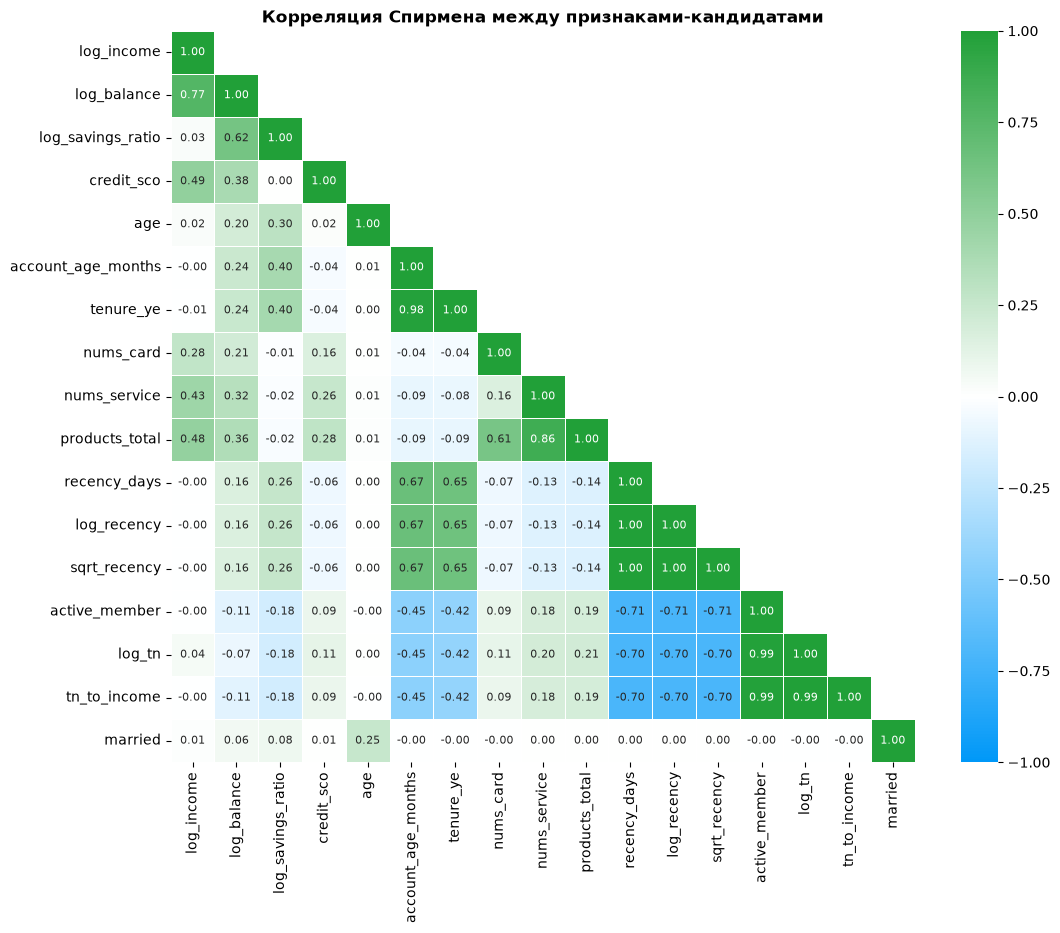

,feature_1,feature_2,rho
182,recency_days,sqrt_recency,1.000000
181,recency_days,log_recency,1.000000
199,log_recency,sqrt_recency,1.000000
253,log_tn,tn_to_income,0.993446
235,active_member,log_tn,0.990358
236,active_member,tn_to_income,0.990358
91,account_age_months,tenure_ye,0.977136
145,nums_service,products_total,0.864988


In [ ]:
corr_c = candidates.corr(method="spearman")
pairs = (corr_c.where(np.triu(np.ones_like(corr_c, dtype=bool), k=1))
         .stack().rename("rho").rename_axis(["feature_1", "feature_2"]).reset_index())
pairs = pairs[pairs["rho"].abs() > 0.8].sort_values("rho", key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 9.5))
m = np.triu(np.ones_like(corr_c, dtype=bool), k=1)
sns.heatmap(corr_c, mask=m, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 8}, linewidths=0.5, linecolor="white")
ax.set_title("Корреляция Спирмена между признаками-кандидатами")
ax.grid(False)
plt.show()
pairs

Решения по сильно коррелированным парам:

* `account_age_months` vs `tenure_ye` (ρ ≈ 0.98) → оставляем непрерывный `account_age_months`;
* `sqrt_recency` / `log_recency` / `recency_days` (монотонные преобразования друг друга, ρ = 1) и `active_member` / `log_tn` / `tn_to_income` (ρ ≈ 0.99) → оставляем `sqrt_recency`
  (непрерывная давность) и `tn_to_income` (он несёт *размер* оборота относительно дохода и коррелирует с остальными слабее, чем `log_tn`);
* `products_total` vs `nums_service` → `products_total` — сумма, оставляем два исходных счётчика;
* `log_balance` vs `log_income` (ρ ≈ 0.77, ниже порога, но близко) → заменяем баланс на `log_savings_ratio`, который несёт
  новую информацию («доля накоплений») и почти не коррелирует с доходом;
* `married` — слабый, плохо интерпретируемый код, связанный только с возрастом (H8) → исключаем.

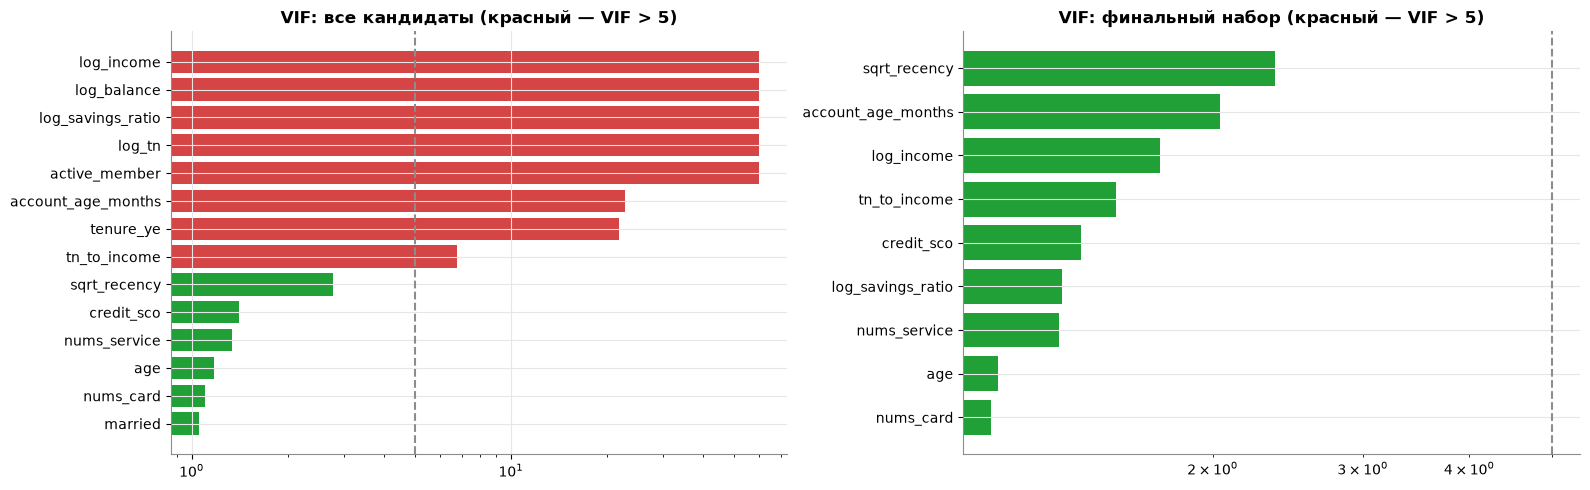

,log_income,log_savings_ratio,credit_sco,age,account_age_months,nums_card,nums_service,sqrt_recency,tn_to_income
VIF,1.73,1.33,1.4,1.12,2.04,1.1,1.32,2.37,1.54


In [20]:
MODEL_FEATURES = [
    "log_income",          # финансы
    "log_savings_ratio",
    "credit_sco",
    "age",                 # жизненный цикл
    "account_age_months",  # отношения с банком
    "nums_card",
    "nums_service",
    "sqrt_recency",        # активность
    "tn_to_income",
]

def vif(frame: pd.DataFrame) -> pd.Series:
    res = {}
    for c in frame.columns:
        others = frame.drop(columns=c)
        r2_ = LinearRegression().fit(others, frame[c]).score(others, frame[c])
        res[c] = 1 / max(1 - r2_, 1e-9)   # защищаемся от точной коллинеарности (VIF = inf)
    return pd.Series(res, name="VIF")


vif_before = vif(candidates.drop(columns=["recency_days", "products_total", "log_recency"]))
vif_after = vif(candidates[MODEL_FEATURES])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, v, title in [(axes[0], vif_before, "все кандидаты"), (axes[1], vif_after, "финальный набор")]:
    v = v.sort_values()
    ax.barh(v.index, v.clip(upper=60), color=[ERROR_RED if x > 5 else GREEN for x in v.values])
    ax.axvline(5, color=GRAY, ls="--"); ax.set_xscale("log")
    ax.set_title(f"VIF: {title} (красный — VIF > 5)")
fig.tight_layout()
plt.show()
vif_after.round(2).to_frame().T

Среди всех кандидатов много признаков с огромным VIF: `log_savings_ratio` — это ровно `log_balance − log_income`
(точная коллинеарность), `tenure_ye` дублирует `account_age_months`, а `active_member`, `log_tn`, `log_recency`, `sqrt_recency`
выражаются друг через друга. В финальном наборе из 9 признаков VIF у всех признаков небольшой (< 5; самый большой — у пары
`sqrt_recency`/`tn_to_income`, что естественно: у неактивных оборот нулевой). Мультиколлинеарность устранена.

### 5.4 Разбиение на train / test

Для кластеризации нет целевой переменной, но отложенная выборка полезна:
* **обобщающая способность** — центроиды / модель, обученные на train, должны давать на test похожие метрики качества и размеры кластеров;
* **стабильность** — кластеры, полученные отдельно на test, должны совпадать с предсказанными моделью с train (ARI);
* так мы имитируем реальный сценарий — присвоение сегмента новым клиентам.

Разбиваем 80 / 20 со стратификацией по `customer_segment × exit`, чтобы доли сегментов и оттока (нужные для
интерпретации) совпадали в обеих частях. Все статистики трансформаций (границы винсоризации, среднее и σ скейлера)
считаем **только по train**.

In [21]:
strat = df["customer_segment"] + "_" + df["exit"].astype(str)
idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=strat)
print(f"train: {len(idx_train)}, test: {len(idx_test)}")
pd.DataFrame({
    "train": df.loc[idx_train, "customer_segment"].value_counts(normalize=True),
    "test": df.loc[idx_test, "customer_segment"].value_counts(normalize=True),
}).assign(exit_train=df.loc[idx_train].groupby("customer_segment")["exit"].mean(),
          exit_test=df.loc[idx_test].groupby("customer_segment")["exit"].mean()).round(3)

train: 64000, test: 16000


,train,test,exit_train,exit_test
customer_segment,,,,
Emerging,0.396,0.396,0.176,0.176
Mass,0.268,0.268,0.395,0.395
Priority,0.196,0.196,0.001,0.001
Affluent,0.140,0.140,0.031,0.031


### 5.5 Винсоризация и масштабирование

* **Винсоризация** по 0,5-му и 99,5-му перцентилям train — срезает остаточные хвосты (в т.ч. цензурированный баланс
  и редкие большие обороты), чтобы отдельные точки не «оттягивали» центроиды K-means.
* **StandardScaler** — все признаки в единицах стандартного отклонения, у каждого одинаковый «голос» в евклидовом расстоянии.

In [22]:
class Winsorizer:
    # Обрезка значений по перцентилям, рассчитанным на train.
    def __init__(self, lower=0.005, upper=0.995):
        self.lower, self.upper = lower, upper

    def fit(self, X: pd.DataFrame):
        self.low_ = X.quantile(self.lower)
        self.high_ = X.quantile(self.upper)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.clip(self.low_, self.high_, axis=1)


X_train_raw = candidates.loc[idx_train, MODEL_FEATURES]
X_test_raw = candidates.loc[idx_test, MODEL_FEATURES]

winsor = Winsorizer().fit(X_train_raw)
scaler = StandardScaler().fit(winsor.transform(X_train_raw))

X_train = pd.DataFrame(scaler.transform(winsor.transform(X_train_raw)), index=idx_train, columns=MODEL_FEATURES)
X_test = pd.DataFrame(scaler.transform(winsor.transform(X_test_raw)), index=idx_test, columns=MODEL_FEATURES)

clipped = ((X_train_raw < winsor.low_) | (X_train_raw > winsor.high_)).mean().mul(100).round(2)
print("Доля обрезанных значений в train, %:\n", clipped.to_dict())
X_train.describe().T[["mean", "std", "min", "max"]].round(2)

Доля обрезанных значений в train, %:
 {'log_income': 0.76, 'log_savings_ratio': 1.0, 'credit_sco': 0.46, 'age': 0.38, 'account_age_months': 0.95, 'nums_card': 0.0, 'nums_service': 0.0, 'sqrt_recency': 0.98, 'tn_to_income': 0.5}


,mean,std,min,max
log_income,0.0,1.0,-2.15,2.17
log_savings_ratio,-0.0,1.0,-2.60,2.64
credit_sco,0.0,1.0,-2.44,2.27
age,-0.0,1.0,-1.82,2.70
account_age_months,0.0,1.0,-1.71,1.72
nums_card,0.0,1.0,-1.34,1.94
nums_service,-0.0,1.0,-1.28,2.21
sqrt_recency,0.0,1.0,-1.83,2.21
tn_to_income,-0.0,1.0,-0.45,4.61


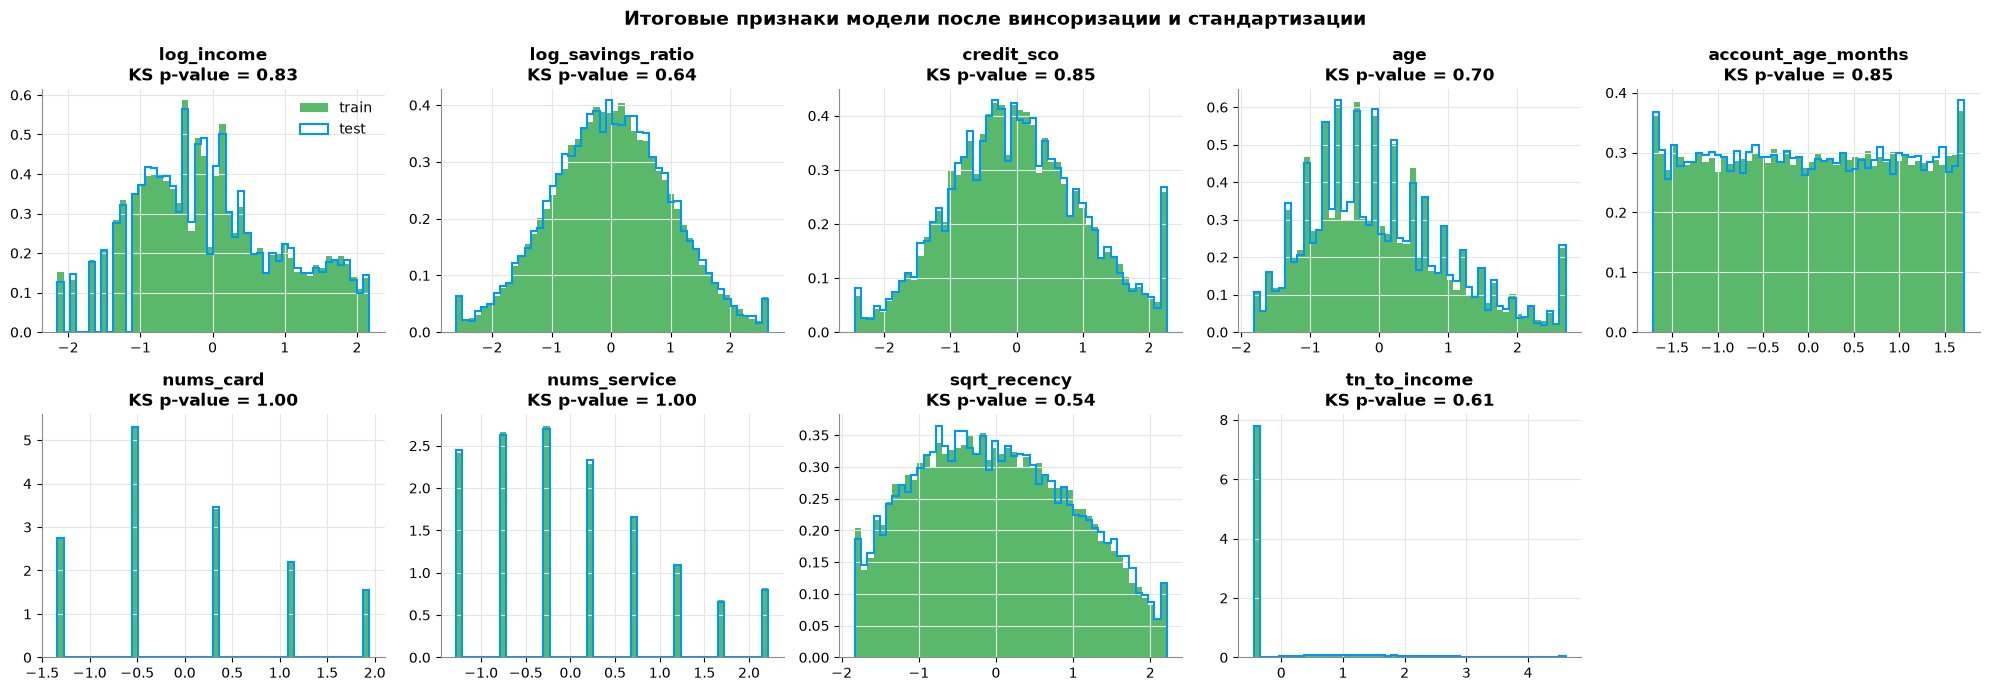

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), MODEL_FEATURES):
    ax.hist(X_train[col], bins=50, color=GREEN, alpha=0.75, density=True, label="train")
    ax.hist(X_test[col], bins=50, histtype="step", color=BLUE, lw=1.5, density=True, label="test")
    ks = stats.ks_2samp(X_train[col], X_test[col]).pvalue
    ax.set_title(f"{col}\nKS p-value = {ks:.2f}")
axes[0, 0].legend()
axes.ravel()[-1].axis("off")
fig.suptitle("Итоговые признаки модели после винсоризации и стандартизации", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

Распределения train и test совпадают (KS-тест не находит различий). Что важно для кластеризации:
* `tn_to_income` — «нуль + хвост»: ~79 % неактивных клиентов стоят в одной точке, активные разбросаны вправо. Этот признак
  почти наверняка станет одной из главных осей разбиения;
* `nums_card`, `nums_service` — дискретные счётчики, образуют «слои» в пространстве;
* `log_income` — дискретная сетка (доход округлён до миллиона) с плечом справа (владельцы бизнеса и руководители);
* `account_age_months` — равномерное распределение: по стажу естественных групп нет, признак будет «резать» пространство произвольно — учтём это при интерпретации.

### 5.6 Внутренняя размерность данных (PCA-диагностика)

Посмотрим, сколько независимых направлений содержит итоговое пространство. Если бы 2–3 компоненты объясняли почти
всю дисперсию, признаки всё ещё были бы избыточны.

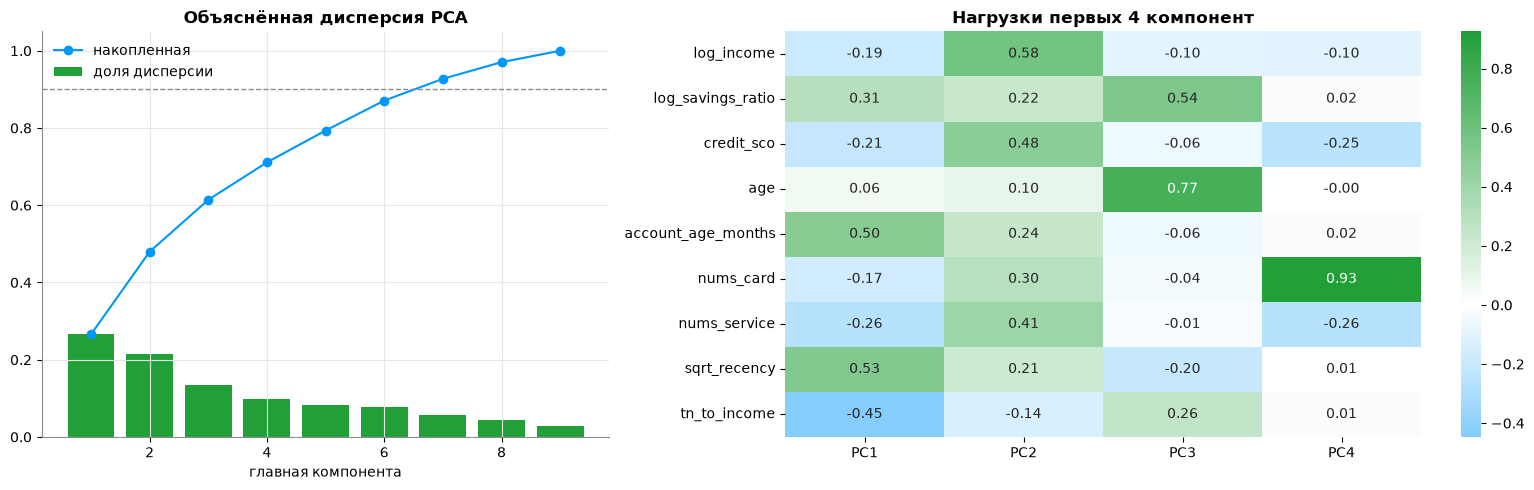

Компонент для 90% дисперсии: 7


In [ ]:
pca = PCA(random_state=RANDOM_STATE).fit(X_train)
evr = pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].bar(range(1, len(evr) + 1), evr, color=GREEN, label="доля дисперсии")
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr), "o-", color=BLUE, label="накопленная")
axes[0].axhline(0.9, color=GRAY, ls="--", lw=1)
axes[0].set_xlabel("главная компонента"); axes[0].set_title("Объяснённая дисперсия PCA")
axes[0].legend()
loadings = pd.DataFrame(pca.components_[:4].T, index=MODEL_FEATURES, columns=[f"PC{i}" for i in range(1, 5)])
sns.heatmap(loadings, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, ax=axes[1])
axes[1].set_title("Нагрузки первых 4 компонент")
axes[1].grid(False)
fig.tight_layout()
plt.show()
print("Компонент для 90% дисперсии:", int(np.searchsorted(np.cumsum(evr), 0.9) + 1))

Дисперсия распределена по компонентам довольно равномерно (для 90 % нужно 7 компонент из 9) — избыточных признаков не осталось.
Первые компоненты хорошо интерпретируются:
* **PC1 — «давно с банком и уснул» vs «новый и активный»**: стаж и давность активности (+) против оборота (−);
* **PC2 — «благосостояние и продукты»**: доход, рейтинг, число услуг и карт;
* **PC3 — «возраст и накопления»**: старшие клиенты держат на счёте больше месячных доходов;
* **PC4 — число карт** как отдельная ось.

Снижать размерность перед кластеризацией не будем — все 9 осей несут смысл; PCA используем в ноутбуке 05 только для визуализации.

## 6. Сохранение результатов

Сохраняем:
* `train.csv`, `test.csv` — масштабированные признаки модели (колонки `z_<признак>`) + колонки для интерпретации (исходные значения и производные/внешние метки);
* `preprocessor.joblib` — винсоризатор, скейлер, список признаков, дата выгрузки;
* `feature_config.json` — описание групп колонок.

In [25]:
INTERPRET_COLS = [
    "id", "age", "gender", "married", "occupation_ru", "origin_province",
    "credit_sco", "balance", "monthly_ir", "tenure_ye", "nums_card", "nums_service",
    "active_member", "last_transaction_month", "recency_days", "balance_capped",
    "customer_segment", "loyalty_level", "engagement_score", "risk_score", "risk_segment",
    "cluster_group", "exit",
]
raw_feature_cols = {f"raw_{c}": candidates[c] for c in MODEL_FEATURES}
meta = df[INTERPRET_COLS].assign(**raw_feature_cols)

# масштабированные признаки сохраняем с префиксом z_, чтобы не путать их с исходными колонками (age, credit_sco, ...)
train_out = pd.concat([X_train.add_prefix("z_"), meta.loc[idx_train]], axis=1)
test_out = pd.concat([X_test.add_prefix("z_"), meta.loc[idx_test]], axis=1)
assert train_out.columns.is_unique
train_out.to_csv(OUT_DIR / "train.csv", index=False)
test_out.to_csv(OUT_DIR / "test.csv", index=False)

joblib.dump({"winsorizer_low": winsor.low_, "winsorizer_high": winsor.high_, "scaler": scaler,
             "features": MODEL_FEATURES, "ref_date": REF_DATE}, OUT_DIR / "preprocessor.joblib")

config = {
    "model_features": MODEL_FEATURES,
    "model_columns": ["z_" + f for f in MODEL_FEATURES],
    "interpret_numeric": ["age", "credit_sco", "balance", "monthly_ir", "tenure_ye", "nums_card",
                          "nums_service", "active_member", "last_transaction_month", "recency_days",
                          "engagement_score", "risk_score"],
    "interpret_categorical": ["customer_segment", "loyalty_level", "risk_segment", "occupation_ru",
                              "gender", "married", "origin_province"],
    "external_labels": ["exit", "cluster_group"],
    "ref_date": str(REF_DATE.date()),
    "random_state": RANDOM_STATE,
}
(OUT_DIR / "feature_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

print("Сохранено:", *sorted(p.name for p in OUT_DIR.iterdir()), sep="\n  ")
print("train:", train_out.shape, "| test:", test_out.shape)

Сохранено:
  feature_config.json
  preprocessor.joblib
  test.csv
  train.csv
train: (64000, 41) | test: (16000, 41)


## Итоги

* Данные чистые: пропусков, дубликатов и противоречий нет; единственная аномалия — цензурированный баланс (50 строк).
* Из 26 колонок **только 9 исходных полей** несут независимую информацию о поведении клиента. Производные признаки
  банка (`customer_segment`, `loyalty_level`, `engagement_score`, `risk_*`) — детерминированные функции исходных, а
  `cluster_group` — готовая сегментация (восстанавливается деревом на 95 %).
* Четыре колонки активности описывают один факт «была ли активность за последние 90 дней».
* Демография (пол, адрес, провинция) не связана с поведением — это шум для расстояний.
* Финальное пространство — 9 масштабированных признаков в четырёх смысловых блоках:
  **финансы** (`log_income`, `log_savings_ratio`, `credit_sco`), **жизненный цикл** (`age`),
  **отношения с банком** (`account_age_months`, `nums_card`, `nums_service`),
  **активность** (`sqrt_recency`, `tn_to_income`).
* Внешние метки `exit` и `cluster_group` и производные признаки сохранены для валидации и интерпретации кластеров в ноутбуке 05.